## Goals
- Identify and handle missing values
- Detect and remove duplicate rows
- Identify and handle outliers

In [23]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
file_path = r"C:\Users\hp\OneDrive\Documents\Data Analysis and Visualization Expertise\Extracted_Files\5-Days-Live-EDA-and-Feature-Engineering-main\Zomato_Dataset\zomato.csv"
df = pd.read_csv(file_path,encoding="latin-1")

In [3]:
# Display first few rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Check Missing Values

In [4]:
# Check for missing values in each column
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [6]:
# Fill missing values with 'Unknown' - replacing missing entries
df['Cuisines'] = df['Cuisines'].fillna('Unknown',inplace=True)

In [7]:
df['Cuisines']

0       None
1       None
2       None
3       None
4       None
        ... 
9546    None
9547    None
9548    None
9549    None
9550    None
Name: Cuisines, Length: 9551, dtype: object

In [10]:
# Replace missing numbers with median
df['Average Cost for two'] = df['Average Cost for two'].fillna(df['Average Cost for two'].median(),inplace=True)
df['Average Cost for two']

0       None
1       None
2       None
3       None
4       None
        ... 
9546    None
9547    None
9548    None
9549    None
9550    None
Name: Average Cost for two, Length: 9551, dtype: object

In [12]:
# Drop rows where Aggregate rating is missing
df['Aggregate rating'] = df.dropna(subset=['Aggregate rating'],inplace=True)
df['Aggregate rating']

0       None
1       None
2       None
3       None
4       None
        ... 
9546    None
9547    None
9548    None
9549    None
9550    None
Name: Aggregate rating, Length: 9551, dtype: object

In [13]:
# Verify that all missing values are handled
df.isnull().sum()

Restaurant ID              0
Restaurant Name            0
Country Code               0
City                       0
Address                    0
Locality                   0
Locality Verbose           0
Longitude                  0
Latitude                   0
Cuisines                9551
Average Cost for two    9551
Currency                   0
Has Table booking          0
Has Online delivery        0
Is delivering now          0
Switch to order menu       0
Price range                0
Aggregate rating        9551
Rating color               0
Rating text                0
Votes                      0
dtype: int64

## Handling Duplicates

In [14]:
# Check how many duplicate rows exist
duplicates = df.duplicated().sum()
print(f"No. of duplicate rows: {duplicates}")

No. of duplicate rows: 0


In [15]:
# Drop duplicate rows if any
df.drop_duplicates(inplace=True)

In [16]:
# Verify duplicates removed
print(f"Duplicates after removal: {df.duplicated().sum()}")

Duplicates after removal: 0


## Handling Outliers Using IQR Method

Outliers can distort analysis. We can handle them in 'Avergae Cost for two'

In [17]:
# Calculate Q1(25th percentile) and Q3(75th percentile).
Q1 = df['Average Cost for two'].quantile(0.25)
Q3 = df['Average Cost for two'].quantile(0.75)
IQR = Q3-Q1

In [18]:
# Define the acceptable range
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

In [19]:
print(f"Lower Bound: {lower_bound}")
print(f"\nUpper Bound: {upper_bound}")

Lower Bound: nan

Upper Bound: nan


In [20]:
# Filter out the outliers
df_no_outliers = df[(df['Average Cost for two']>=lower_bound) & (df['Average Cost for two']<=upper_bound)]

In [21]:
print(f"Original Rows: {len(df)}")
print(f"\nRows after removing outliers: {len(df_no_outliers)}")

Original Rows: 9551

Rows after removing outliers: 0


## Visualizing Outliers

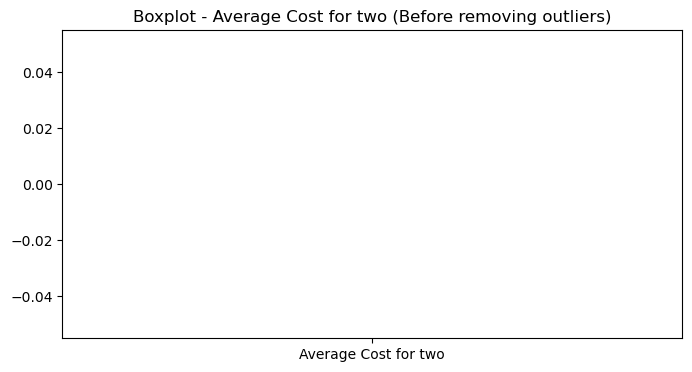

In [27]:
# Boxplot to visually check for outliers
plt.figure(figsize=(8,4))

# Use matplotlib's boxplot directly
plt.boxplot(df['Average Cost for two'].dropna())
plt.title('Boxplot - Average Cost for two (Before removing outliers)')
plt.xticks([1], ['Average Cost for two'])
plt.show()

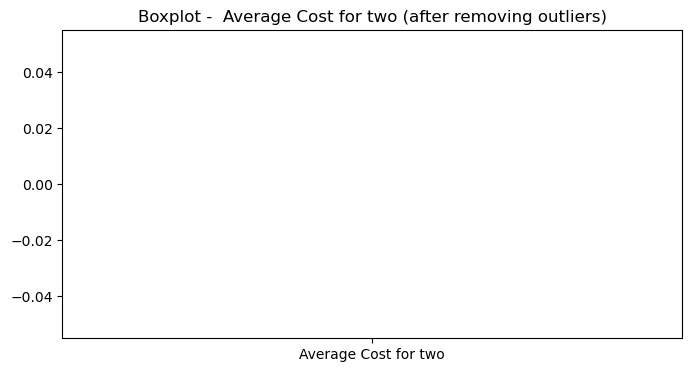

In [30]:
# Boxplot after removing outliers
plt.figure(figsize=(8,4))
plt.boxplot(df_no_outliers['Average Cost for two'].dropna())
plt.title('Boxplot -  Average Cost for two (after removing outliers)')
plt.xticks([1], ['Average Cost for two'])
plt.show()

In [31]:
# Boxplot after removing outliers
plt.figure(figsize=(8,4))

# First, check if the column exists and has non-null values
if 'Average Cost for two' in df_no_outliers.columns:
    data = df_no_outliers['Average Cost for two'].dropna()
    print(f"Number of non-null values: {len(data)}")
    print(f"Data range: Min={data.min()}, Max={data.max()}")
    
    # Only create boxplot if there's data
    if len(data) > 0:
        plt.boxplot(data)
        plt.title('Boxplot - Average Cost for two (after removing outliers)')
        plt.xticks([1], ['Average Cost for two'])
        plt.ylabel('Cost')
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        print("No data to plot after removing NaN values")
else:
    # If column doesn't exist, print all available columns
    print("Column 'Average Cost for two' not found.")
    print("Available columns:", df_no_outliers.columns.tolist())
    
plt.show()

Number of non-null values: 0
Data range: Min=nan, Max=nan
No data to plot after removing NaN values


<Figure size 800x400 with 0 Axes>

## Summary - Markdown Cell

## 🧹 Day 3 — Data Cleaning Summary

**Steps performed:**
- Identified missing values using `df.isnull().sum()`
- Filled missing values:
  - Replaced missing text values in *Cuisines* with 'Unknown'
  - Replaced missing numeric values in *Average Cost for two* with median
- Dropped rows with missing *Aggregate rating*
- Removed duplicate rows using `drop_duplicates()`
- Detected and handled outliers in *Average Cost for two* using IQR
- Visualized outliers using boxplots (before & after cleaning)

✅ The dataset is now clean and ready for analysis.
